In [1]:
import pandas as pd
import os
from gensim.models import LdaSeqModel
from gensim.corpora import Dictionary, MmCorpus
from sklearn.preprocessing import KBinsDiscretizer
from collections import Counter
import numpy as np
import datetime
import time
from itertools import chain
import nltk
from nltk.corpus import stopwords
from gensim.utils import simple_preprocess
import logging
from gensim.models import CoherenceModel
import spacy

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)


In [3]:
import plotly.graph_objects as go
import numpy as np

In [4]:
df = pd.read_pickle("input_files/diarium.pk")


In [5]:
df

,date,text
0,1703-08-13,Auss Wienn von biss Augusti 1703.
1,1703-08-13,DEn dito hat man dass die Land Militz welche ...
2,1703-08-13,Wie verlautet seynd Käyserl.
3,1703-08-13,in stehende Regimenter beordert ihren March ...
4,1703-08-13,Gestern ist ein Courier von der Armée auss Jta...
...,...,...
79777,1798-10-03,"Praktische französische Grammatik, wodurch man..."
79778,1798-10-03,"Von Johann Valentin Meidinger, Lehrer der fran..."
79779,1798-10-03,Fünfzehnte durchaus verbesserte und nach Waill...
79780,1798-10-03,Frankfurt und Leipzig 1799.


In [98]:
df

,date,text,full_text,year,tokens
0,1703-08-13,Wienn Augusti 1703.,Auss Wienn von biss Augusti 1703.,1703,"[Wienn, Augusti, 1703.]"
1,1703-08-13,dito Land Militz Oesterreich auffgebotten thei...,DEn dito hat man dass die Land Militz welche ...,1703,"[dito, Land, Militz, Oesterreich, auffgebotten..."
2,1703-08-13,verlautet seynd Käyserl,Wie verlautet seynd Käyserl.,1703,"[verlautet, seynd, Käyserl]"
3,1703-08-13,stehende Regimenter beordert March schlei nig ...,in stehende Regimenter beordert ihren March ...,1703,"[stehende, Regimenter, beordert, March, schlei..."
4,1703-08-13,Gestern Courier Armée Jtalien arrivirt Bericht...,Gestern ist ein Courier von der Armée auss Jta...,1703,"[Gestern, Courier, Armée, Jtalien, arrivirt, B..."
...,...,...,...,...,...
79777,1798-10-03,Praktische französische Grammatik wodurch Spra...,"Praktische französische Grammatik, wodurch man...",1798,"[Praktische, französische, Grammatik, wodurch,..."
79778,1798-10-03,Johann Valentin Meidinger Lehrer französischen...,"Von Johann Valentin Meidinger, Lehrer der fran...",1798,"[Johann, Valentin, Meidinger, Lehrer, französi..."
79779,1798-10-03,Fünfzehnte verbesserte Wailly umgearbeitete Au...,Fünfzehnte durchaus verbesserte und nach Waill...,1798,"[Fünfzehnte, verbesserte, Wailly, umgearbeitet..."
79780,1798-10-03,Frankfurt Leipzig 1799.,Frankfurt und Leipzig 1799.,1798,"[Frankfurt, Leipzig, 1799.]"


In [6]:
nlp = spacy.load("de_core_news_sm")

In [7]:
nltk.download('stopwords')

# Load standard German stopwords
german_stopwords = set(stopwords.words('german'))

# Add your custom misspelled stopwords
from tqdm import tqdm


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\krusic\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
def remove_stopwords(text):
    doc = nlp(text)
    return " ".join([
        token.text for token in doc
        if token.text.lower() not in combined_stopwords
        and not token.is_punct
        and not token.is_space
    ])

In [9]:

# Step 1: Get spaCy's default German stopwords
modern_stopwords = nlp.Defaults.stop_words

# Step 2: Define your custom historical stopwords
historical_stopwords = {
    "auff", "umb", "bey", "worden", "solle", "seye", "jhro", "jhre", "dero",
    "allerhöchst", "gnädigst", "wohlgeboren", "gedachte", "besagte", "solches",
    "solchergestalt", "dergestalt", "welches", "welchen", "welcher", "mitunter",
    "hievon", "hiezu", "hiermit", "allhie", "dahin", "desselben", "derselben",
    "denselben", "zuvor", "nachgehends", "allenthalben", "allzeit", "gnädiger",
    "hochfürstlich", "hochlöblich", "durchl", "widerum", "gleichwie", "umbständ",
    "solch", "hingegen", "dieweil", "allda","auss", "biss"

}

# Step 3: Combine them
combined_stopwords = modern_stopwords.union(historical_stopwords)

# Optional: print a sample
print(f"Total stopwords: {len(combined_stopwords)}")
print(sorted(list(combined_stopwords))[:20])  # show sample


Total stopwords: 580
['a', 'ab', 'aber', 'ach', 'acht', 'achte', 'achten', 'achter', 'achtes', 'ag', 'allda', 'alle', 'allein', 'allem', 'allen', 'allenthalben', 'aller', 'allerdings', 'allerhöchst', 'alles']


In [10]:

texts = df['text'].tolist()
cleaned_texts = []

for doc in tqdm(nlp.pipe(texts, batch_size=50, n_process=1), total=len(texts)):
    tokens = [
        token.text for token in doc
        if token.text.lower() not in combined_stopwords
        and not token.is_punct
        and not token.is_space
    ]
    cleaned_texts.append(" ".join(tokens))

df['full_text'] = df['text']
df['text'] = cleaned_texts


100%|███████████████████████████████████████████████████████████████████████████| 79782/79782 [04:14<00:00, 313.56it/s]


In [11]:
df['year'] = pd.to_datetime(df['date']).dt.year

# --- Tokenize the 'text' column (basic whitespace split) ---
df['tokens'] = df['text'].str.split()



In [12]:
df

,date,text,full_text,year,tokens
0,1703-08-13,Wienn Augusti 1703.,Auss Wienn von biss Augusti 1703.,1703,"[Wienn, Augusti, 1703.]"
1,1703-08-13,dito Land Militz Oesterreich auffgebotten thei...,DEn dito hat man dass die Land Militz welche ...,1703,"[dito, Land, Militz, Oesterreich, auffgebotten..."
2,1703-08-13,verlautet seynd Käyserl,Wie verlautet seynd Käyserl.,1703,"[verlautet, seynd, Käyserl]"
3,1703-08-13,stehende Regimenter beordert March schlei nig ...,in stehende Regimenter beordert ihren March ...,1703,"[stehende, Regimenter, beordert, March, schlei..."
4,1703-08-13,Gestern Courier Armée Jtalien arrivirt Bericht...,Gestern ist ein Courier von der Armée auss Jta...,1703,"[Gestern, Courier, Armée, Jtalien, arrivirt, B..."
...,...,...,...,...,...
79777,1798-10-03,Praktische französische Grammatik wodurch Spra...,"Praktische französische Grammatik, wodurch man...",1798,"[Praktische, französische, Grammatik, wodurch,..."
79778,1798-10-03,Johann Valentin Meidinger Lehrer französischen...,"Von Johann Valentin Meidinger, Lehrer der fran...",1798,"[Johann, Valentin, Meidinger, Lehrer, französi..."
79779,1798-10-03,Fünfzehnte verbesserte Wailly umgearbeitete Au...,Fünfzehnte durchaus verbesserte und nach Waill...,1798,"[Fünfzehnte, verbesserte, Wailly, umgearbeitet..."
79780,1798-10-03,Frankfurt Leipzig 1799.,Frankfurt und Leipzig 1799.,1798,"[Frankfurt, Leipzig, 1799.]"


In [144]:
N_TOPICS = 50
N_BINS = 60
RANDOM_STATE = 42
MODEL_DIR = 'models/ldaseq_models'
os.makedirs(MODEL_DIR, exist_ok=True)
timestamp_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = f'ldaseq_{N_TOPICS}topics_{N_BINS}bins_{timestamp_str}'
model_path = os.path.join(MODEL_DIR, model_name)
os.makedirs(model_path)


In [145]:
# --- Prepare documents and timestamps ---
documents = df['tokens'].tolist()
timestamps = df['year'].tolist()
assert len(documents) == len(timestamps)

In [146]:
discretizer = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile')
time_bins = discretizer.fit_transform(np.array(timestamps).reshape(-1, 1)).astype(int).flatten()
bin_counts = Counter(time_bins)
time_slice = [bin_counts.get(i, 0) for i in range(N_BINS)]

C:\Users\krusic\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:279: UserWarning:

Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.



In [147]:
dictionary = Dictionary(documents)
corpus = [dictionary.doc2bow(doc) for doc in documents]


2025-10-02 19:29:53,220 - INFO - adding document #0 to Dictionary<0 unique tokens: []>
2025-10-02 19:29:53,372 - INFO - adding document #10000 to Dictionary<35078 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:53,551 - INFO - adding document #20000 to Dictionary<58156 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:53,721 - INFO - adding document #30000 to Dictionary<76817 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:53,902 - INFO - adding document #40000 to Dictionary<95294 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:54,086 - INFO - adding document #50000 to Dictionary<114908 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:54,288 - INFO - adding document #60000 to Dictionary<134541 unique tokens: ['1703.', 'Augusti', 'Wienn', 'Land', 'Militz']...>
2025-10-02 19:29:54,476 - INFO - adding document #700

In [33]:
dict_path = os.path.join(model_path, 'dictionary-50.dict')
corpus_path = os.path.join(model_path, 'corpus-50.mm')
dictionary.save(dict_path)
MmCorpus.serialize(corpus_path, corpus)


2025-10-01 19:24:37,547 - INFO - Dictionary lifecycle event {'fname_or_handle': 'models/ldaseq_models\\ldaseq_50topics_60bins_20251001_192434\\dictionary-50.dict', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-10-01T19:24:37.547933', 'gensim': '4.2.1.dev0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-10-01 19:24:37,602 - INFO - saved models/ldaseq_models\ldaseq_50topics_60bins_20251001_192434\dictionary-50.dict
2025-10-01 19:24:37,603 - INFO - storing corpus in Matrix Market format to models/ldaseq_models\ldaseq_50topics_60bins_20251001_192434\corpus-50.mm
2025-10-01 19:24:37,603 - INFO - saving sparse matrix to models/ldaseq_models\ldaseq_50topics_60bins_20251001_192434\corpus-50.mm
2025-10-01 19:24:37,604 - INFO - PROGRESS: saving document #0
2025-10-01 19:24:37,620 - INFO - PROGRESS: saving document #1000
2025-10-01

In [34]:
print("🔄 Starting LdaSeqModel training...")
start_time = time.time()


🔄 Starting LdaSeqModel training...


In [35]:
ldaseq = LdaSeqModel(
    corpus=corpus,
    time_slice=time_slice,
    id2word=dictionary,
    num_topics=N_TOPICS,
    chain_variance=0.005,
    lda_inference_max_iter=5,
    em_max_iter=5,
    random_state=RANDOM_STATE
)



2025-10-01 19:24:38,837 - INFO - using symmetric eta at 0.02
2025-10-01 19:24:38,853 - INFO - using serial LDA version on this node
2025-10-01 19:24:39,494 - INFO - running online (multi-pass) LDA training, 50 topics, 10 passes over the supplied corpus of 79782 documents, updating model once every 2000 documents, evaluating perplexity every 20000 documents, iterating 50x with a convergence threshold of 0.001000
2025-10-01 19:24:39,495 - INFO - PROGRESS: pass 0, at document #2000/79782
2025-10-01 19:24:40,084 - INFO - merging changes from 2000 documents into a model of 79782 documents
2025-10-01 19:24:40,454 - INFO - topic #38 (0.010): 0.013*"Kayserl" + 0.011*"General" + 0.008*"Feld" + 0.006*"Stich" + 0.005*"weilen" + 0.004*"etliche" + 0.004*"Currier" + 0.004*"ver" + 0.004*"dito" + 0.004*"Marschallen"
2025-10-01 19:24:40,458 - INFO - topic #37 (0.010): 0.023*"Herr" + 0.008*"Majest" + 0.008*"Herrn" + 0.007*"Graf" + 0.006*"Titl" + 0.006*"Johann" + 0.006*"General" + 0.005*"Stadt" + 0.005*"

In [36]:
end_time = time.time()
duration_minutes = (end_time - start_time) / 60
print(f"✅ LdaSeqModel training complete in {duration_minutes:.2f} minutes.")


✅ LdaSeqModel training complete in 69.25 minutes.


In [37]:
ldaseq.save(os.path.join(model_path, 'ldaseq_model-tokenized-50'))

print(f"\n✔️ LdaSeqModel trained and saved in: {model_path}")



2025-10-01 20:33:53,842 - INFO - LdaSeqModel lifecycle event {'fname_or_handle': 'models/ldaseq_models\\ldaseq_50topics_60bins_20251001_192434\\ldaseq_model-tokenized-50', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-10-01T20:33:53.840410', 'gensim': '4.2.1.dev0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'saving'}
2025-10-01 20:34:48,784 - INFO - saved models/ldaseq_models\ldaseq_50topics_60bins_20251001_192434\ldaseq_model-tokenized-50



✔️ LdaSeqModel trained and saved in: models/ldaseq_models\ldaseq_50topics_60bins_20251001_192434


In [38]:
# Print top 10 words per topic at each time slice
for time in range(len(ldaseq.time_slice)):
    print(f"\n--- Time Slice {time} ---")
    topics = ldaseq.print_topics(time=time, top_terms=10)
    for topic_id, topic in enumerate(topics):
        print(f"Topic {topic_id}: {topic}")



--- Time Slice 0 ---
Topic 0: [('Stadt', 0.11633945253134871), ('erhoben', 0.021695739717412208), ('Ehren', 0.020565832444890245), ('Feuer', 0.019008261863414557), ('Besatzung', 0.016744171507134645), ('dasigen', 0.014700328791102682), ('Pallast', 0.014601874031764753), ('Gewehr', 0.013472647301132484), ('ster', 0.011494740925990983), ('künftigen', 0.011226236188840926)]
Topic 1: [('Sachen', 0.05327930977833715), ('selbige', 0.05327930599319867), ('Jndessen', 0.04606557453686226), ('dergleichen', 0.0422252647701056), ('Genua', 0.035942355484400675), ('Rede', 0.026458488843074973), ('versichert', 0.02329444151851779), ('Fran', 0.02150598230444535), ('Audientz', 0.01949049380620176), ('Flotte', 0.01785016656077064)]
Topic 2: [('wider', 0.01830687712390971), ('ge', 0.016928987523686653), ('all', 0.010223092287942765), ('geben', 0.00887922590425169), ('lassen', 0.008826637076933232), ('ben', 0.006767936492031961), ('wolle', 0.005549726938090427), ('ver', 0.005042972861315896), ('wissen', 

In [39]:
# Set output file path
output_path = "ldaseq_topics_over_time-tokenized-50.txt"

with open(output_path, "w", encoding="utf-8") as f:
    for time in range(len(ldaseq.time_slice)):
        f.write(f"\n--- Time Slice {time} ---\n")
        topics = ldaseq.print_topics(time=time, top_terms=10)
        for topic_id, topic in enumerate(topics):
            f.write(f"Topic {topic_id}: {topic}\n")

print(f"✔️ Topics saved to: {output_path}")


✔️ Topics saved to: ldaseq_topics_over_time-tokenized-50.txt


In [20]:
import numpy as np
import plotly.graph_objects as go

def plot_ldaseq_topic_proportions(ldaseq, topic_ids=None):
    """
    Plots average topic proportions over time for selected topics in a LdaSeqModel.

    Parameters:
        ldaseq     : Trained LdaSeqModel
        topic_ids  : Optional list of topic indices to plot (e.g., [0, 3, 5]).
                     If None, all topics will be plotted.
    """
    n_topics = ldaseq.num_topics
    n_times = len(ldaseq.time_slice)

    if topic_ids is None:
        topic_ids = list(range(n_topics))

    avg_topic_props = []

    for t in range(n_times):
        topic_dists = ldaseq.doc_topics(t)

        if topic_dists.ndim == 1:
            topic_dists = topic_dists.reshape(1, -1)

        avg = np.mean(topic_dists, axis=0)
        avg_topic_props.append(avg)

    avg_topic_props = np.array(avg_topic_props)

    fig = go.Figure()

    for topic_id in topic_ids:
        if topic_id >= avg_topic_props.shape[1]:
            raise ValueError(f"Topic ID {topic_id} is out of range for model with {n_topics} topics.")
        fig.add_trace(go.Scatter(
            x=list(range(n_times)),
            y=avg_topic_props[:, topic_id],
            mode='lines+markers',
            name=f"Topic {topic_id}"
        ))

    fig.update_layout(
        title="Average Topic Proportions Over Time (LdaSeqModel)",
        xaxis_title="Time Slice",
        yaxis_title="Average Proportion",
        legend_title="Topic",
        template="plotly_white"
    )

    fig.show()


In [21]:
import numpy as np
import pandas as pd
import plotly.express as px

def plot_ldaseq_heatmap(ldaseq):
    n_topics = ldaseq.num_topics
    n_times = len(ldaseq.time_slice)

    heatmap_data = []

    for t in range(n_times):
        doc_topic_dist = ldaseq.doc_topics(t)
        
        # Ensure 2D shape
        if doc_topic_dist.ndim == 1:
            doc_topic_dist = doc_topic_dist.reshape(1, -1)

        avg_dist = np.mean(doc_topic_dist, axis=0)

        for topic_id in range(n_topics):
            heatmap_data.append({
                "Time Slice": t,
                "Topic": f"Topic {topic_id}",
                "Proportion": avg_dist[topic_id]
            })

    df = pd.DataFrame(heatmap_data)

    fig = px.imshow(
        df.pivot(index="Topic", columns="Time Slice", values="Proportion"),
        labels=dict(color="Avg. Proportion"),
        color_continuous_scale="Blues",
        title="Topic Prevalence Over Time (LdaSeqModel)",
        aspect="auto"
    )

    fig.update_layout(
        xaxis_title="Time Slice",
        yaxis_title="Topic",
        template="plotly_white"
    )

    fig.show()


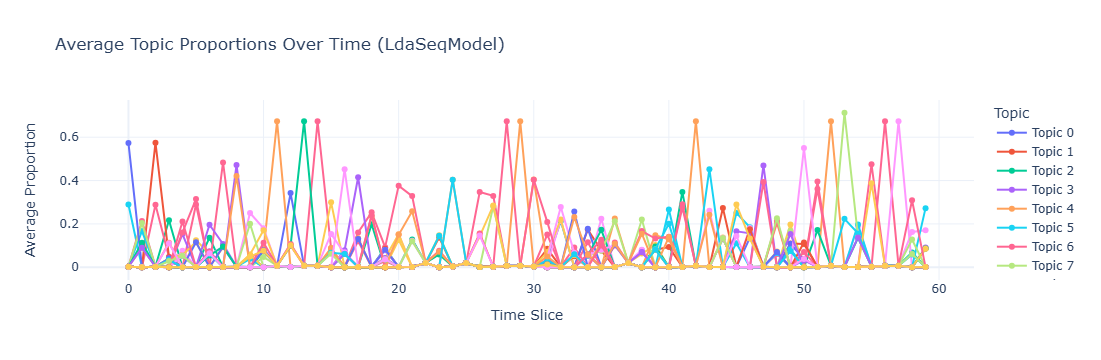

In [22]:
plot_ldaseq_topic_proportions(ldaseq)

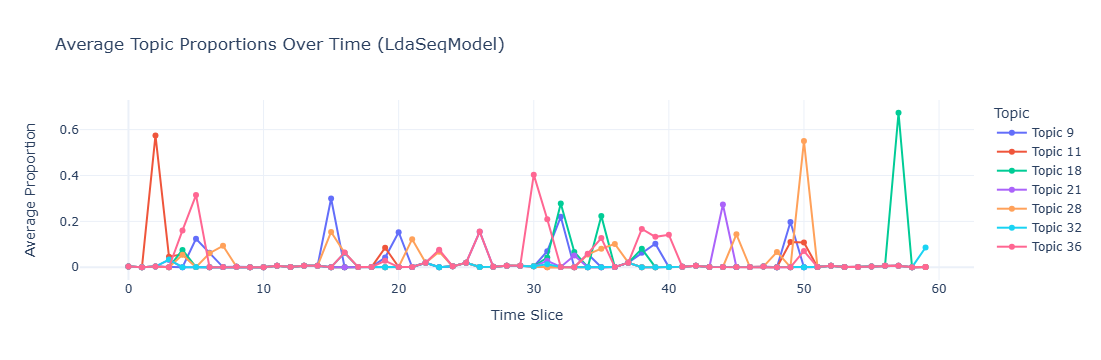

In [23]:
plot_ldaseq_topic_proportions(ldaseq, topic_ids=[9,11,18,21,28,32,36])

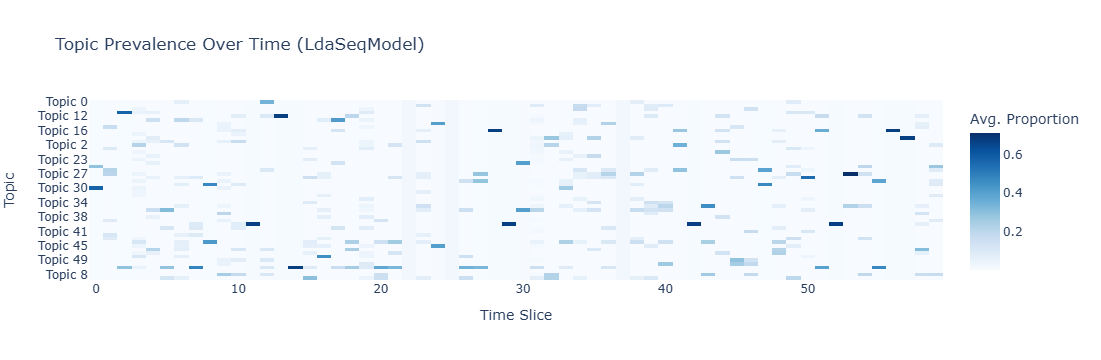

In [24]:
plot_ldaseq_heatmap(ldaseq)


In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

def wordclouds_from_txt(txtoutput_path, target_topics=[1, 4], target_time=0, topn=20):
    """
    Read printed LdaSeq topic output from file and generate word clouds for specific topics.
    """
    with open(txtoutput_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    current_time_slice = None
    topic_lines = []

    # Collect topic lines for the selected time slice
    for line in lines:
        line = line.strip()

        if line.startswith("--- Time Slice"):
            # Extract time slice number
            match = re.search(r"Time Slice (\d+)", line)
            if match:
                current_time_slice = int(match.group(1))
        elif any(f"Topic {t}:" in line for t in target_topics) and current_time_slice == target_time:
            topic_lines.append(line)

    if not topic_lines:
        print(f"❌ No topics found for Time Slice {target_time} and topics {target_topics}")
        return

    # Generate word clouds
    fig, axes = plt.subplots(1, len(topic_lines), figsize=(6 * len(topic_lines), 5))
    if len(topic_lines) == 1:
        axes = [axes]

    for i, topic_line in enumerate(topic_lines):
        try:
            topic_id_match = re.search(r"Topic (\d+):", topic_line)
            topic_id = int(topic_id_match.group(1)) if topic_id_match else i
            word_weight_str = topic_line.split(":", 1)[1].strip()
            word_weights_list = eval(word_weight_str)[:topn]  # Safely parse

            # Convert to {word: weight} dict
            word_weights = {word: float(weight) for word, weight in word_weights_list}

            wc = WordCloud(width=600, height=400, background_color="white")
            wc.generate_from_frequencies(word_weights)

            axes[i].imshow(wc, interpolation='bilinear')
            axes[i].axis("off")
            axes[i].set_title(f"Topic {topic_id} — Time Slice {target_time}", fontsize=14)

        except Exception as e:
            print(f"❌ Error processing topic line: {e}")

    plt.tight_layout()
    plt.show()


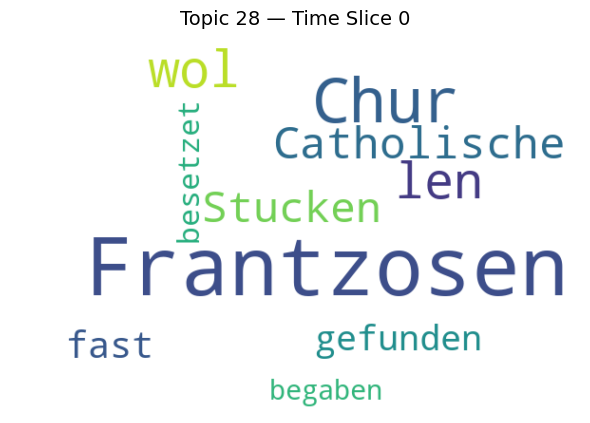

In [117]:
wordclouds_from_txt("ldaseq_topics_over_time-tokenized-50.txt", target_topics=[28], target_time=0, topn=20)


In [46]:
texts = documents


In [1]:
def compute_cv_coherence(ldaseq_model, dictionary, texts, top_n=10):
    """
    Computes c_v coherence over time slices of a trained LdaSeqModel.
    
    Parameters:
        ldaseq_model: Trained LdaSeqModel
        dictionary: Gensim dictionary object
        texts: List of tokenized documents
        top_n: Number of top terms to consider per topic
        
    Returns:
        List of (time_slice_index, c_v coherence score)
    """
    n_bins = len(ldaseq_model.time_slice)
    num_topics = ldaseq_model.num_topics
    coherence_per_time = []

    for time_slice_index in range(n_bins):
        logging.info(f"[COHERENCE] Computing c_v for time slice {time_slice_index}...")
        topics = [
            [term for term, _ in ldaseq_model.print_topic(topic_id, time=time_slice_index, top_terms=top_n)]
            for topic_id in range(num_topics)
        ]

        cm = CoherenceModel(
            topics=topics,
            texts=texts,                 # Needed for c_v
            dictionary=dictionary,
            coherence='c_v'
        )
        score = cm.get_coherence()
        coherence_per_time.append((time_slice_index, score))
        logging.info(f"[DONE] Time slice {time_slice_index}: c_v coherence = {score:.4f}")

    return coherence_per_time


In [ ]:
coherence_scores_cv = compute_cv_coherence(ldaseq, dictionary, documents)
avg_cv = sum(score for _, score in coherence_scores_cv) / len(coherence_scores_cv)

print("\n📈 Final c_v Coherence Scores:")
for time_slice_index, score in coherence_scores_cv:
    print(f"🕒 Time slice {time_slice_index}: {score:.4f}")

print(f"\n📊 Average c_v coherence: {avg_cv:.4f}")


In [19]:
model_path = 'models/ldaseq_models/ldaseq_50topics_60bins_20251001_192434/ldaseq_model-tokenized-50'
ldaseq = LdaSeqModel.load(model_path)


2025-10-02 17:43:57,423 - INFO - loading LdaSeqModel object from models/ldaseq_models/ldaseq_50topics_60bins_20251001_192434/ldaseq_model-tokenized-50
2025-10-02 17:44:15,836 - INFO - loading id2word recursively from models/ldaseq_models/ldaseq_50topics_60bins_20251001_192434/ldaseq_model-tokenized-50.id2word.* with mmap=None
2025-10-02 17:44:15,838 - INFO - LdaSeqModel lifecycle event {'fname': 'models/ldaseq_models/ldaseq_50topics_60bins_20251001_192434/ldaseq_model-tokenized-50', 'datetime': '2025-10-02T17:44:15.838266', 'gensim': '4.2.1.dev0', 'python': '3.11.7 | packaged by Anaconda, Inc. | (main, Dec 15 2023, 18:05:47) [MSC v.1916 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26100-SP0', 'event': 'loaded'}


In [7]:
def compute_topic_diversity(ldaseq_model, time=0, top_n=10):
    num_topics = ldaseq_model.num_topics
    top_words = [
        [word for word, prob in ldaseq_model.print_topic(topic=topic_id, time=time, top_terms=top_n)]
        for topic_id in range(num_topics)
    ]
    all_words = list(chain.from_iterable(top_words))
    unique_words = set(all_words)
    diversity = len(unique_words) / (num_topics * top_n)
    return diversity

In [8]:
print(ldaseq.time_slice)
print(f"Loaded model has {len(ldaseq.time_slice)} time bins")


[1168, 1331, 990, 1724, 1289, 1163, 829, 1834, 970, 1715, 1612, 2208, 1303, 1240, 1338, 1359, 1862, 983, 1105, 1072, 1773, 1700, 1295, 1344, 1117, 1092, 2313, 1205, 1043, 2106, 2472, 2493, 1518, 1789, 1877, 1696, 1425, 2299, 3057, 2092, 2545, 2112, 3772, 8552, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Loaded model has 60 time bins


In [9]:
def compute_avg_topic_diversity(ldaseq_model, top_n=10):
    n_bins = len(ldaseq_model.time_slice)
    diversities = [
        compute_topic_diversity(ldaseq_model, time=i, top_n=top_n)
        for i in range(n_bins)
    ]
    return sum(diversities) / n_bins


In [10]:
avg_diversity = compute_avg_topic_diversity(ldaseq, top_n=10)
print(f"📊 Average topic diversity across all {len(ldaseq.time_slice)} time bins: {avg_diversity:.3f}")


📊 Average topic diversity across all 60 time bins: 0.980


In [11]:
def compute_fast_coherence(ldaseq_model, dictionary, top_n=10):
    n_bins = len(ldaseq_model.time_slice)
    num_topics = ldaseq_model.num_topics
    coherence_per_time = []

    for time_slice_index in range(n_bins):
        logging.info(f"[COHERENCE] Computing u_mass for time slice {time_slice_index}...")
        topics = [
            [term for term, _ in ldaseq_model.print_topic(topic_id, time=time_slice_index, top_terms=top_n)]
            for topic_id in range(num_topics)
        ]

        cm = CoherenceModel(
            topics=topics,
            dictionary=dictionary,
            coherence='u_mass'  # Very fast
        )
        score = cm.get_coherence()
        coherence_per_time.append((time_slice_index, score))
        logging.info(f"[DONE] Time slice {time_slice_index}: u_mass coherence = {score:.4f}")

    return coherence_per_time


In [127]:
ldaseq.print_topic(0)

[('Stadt', 0.11633945253134871),
 ('erhoben', 0.021695739717412208),
 ('Ehren', 0.020565832444890245),
 ('Feuer', 0.019008261863414557),
 ('Besatzung', 0.016744171507134645),
 ('dasigen', 0.014700328791102682),
 ('Pallast', 0.014601874031764753),
 ('Gewehr', 0.013472647301132484),
 ('ster', 0.011494740925990983),
 ('künftigen', 0.011226236188840926),
 ('verstorbenen', 0.010571773254273931),
 ('Mannschaft', 0.010257761784146198),
 ('Anhang', 0.010115023712911776),
 ('CARL', 0.009797106264985199),
 ('Churfürsten', 0.009041829198566104),
 ('hielten', 0.00862047544936753),
 ('ches', 0.008367318228033545),
 ('Bruder', 0.007587120393186619),
 ('Canonen', 0.007342386718306465),
 ('schöne', 0.007065476284768009)]

In [ ]:

corpus = [dictionary.doc2bow(text) for text in texts]

coherence_scores = compute_fast_coherence(ldaseq, dictionary, corpus)
avg_umass = sum(score for _, score in coherence_scores) / len(coherence_scores)
print(f"\n📊 Average u_mass coherence: {avg_umass:.4f}")

In [ ]:
coherence_scores = compute_fast_coherence(ldaseq, dictionary)
avg_umass = sum(score for _, score in coherence_scores) / len(coherence_scores)
print(f"\n📊 Average u_mass coherence: {avg_umass:.4f}")


In [22]:
from gensim.models.coherencemodel import CoherenceModel
import logging

def compute_cv_coherence_fast(ldaseq_model, dictionary, texts, top_n=10):
    """
    Computes c_v coherence for each time slice in an optimized way.
    
    Parameters:
        ldaseq_model : Trained LdaSeqModel
        dictionary    : Gensim Dictionary
        texts         : List of tokenized documents (entire corpus)
        top_n         : Number of top terms per topic
    
    Returns:
        List of (time_slice_index, c_v coherence score)
    """
    n_bins = len(ldaseq_model.time_slice)
    num_topics = ldaseq_model.num_topics
    coherence_per_time = []

    # Reuse a single instance of CoherenceModel per time slice
    for time_slice_index in range(n_bins):
        topics = [
            [term for term, _ in ldaseq_model.print_topic(topic_id, time=time_slice_index, top_terms=top_n)]
            for topic_id in range(num_topics)
        ]

        # Compute coherence using c_v
        cm = CoherenceModel(
            topics=topics,
            texts=texts,  # Full corpus; Gensim needs this for c_v
            dictionary=dictionary,
            coherence='c_v',
            topn=top_n
        )

        score = cm.get_coherence()
        coherence_per_time.append((time_slice_index, score))
        print(f"✓ Time slice {time_slice_index}: c_v coherence = {score:.4f}")

    return coherence_per_time


In [71]:
print(f"Model has {len(ldaseq.time_slice)} time slices.")


Model has 60 time slices.


In [23]:
from joblib import Parallel, delayed

def compute_cv_for_slice(ldaseq_model, dictionary, texts, top_n, time_slice_index):
    topics = [
        [term for term, _ in ldaseq_model.print_topic(topic_id, time=time_slice_index, top_terms=top_n)]
        for topic_id in range(ldaseq_model.num_topics)
    ]
    cm = CoherenceModel(
        topics=topics,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v',
        topn=top_n
    )
    return time_slice_index, cm.get_coherence()

def compute_cv_coherence_parallel(ldaseq_model, dictionary, texts, top_n=10, n_jobs=4):
    n_bins = len(ldaseq_model.time_slice)
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_cv_for_slice)(ldaseq_model, dictionary, texts, top_n, i) for i in range(n_bins)
    )
    for i, score in results:
        print(f"✓ Time slice {i}: c_v coherence = {score:.4f}")
    return results


In [ ]:
coherence_scores_cv = compute_cv_coherence_fast(ldaseq, dictionary, documents)
avg_cv = sum(score for _, score in coherence_scores_cv) / len(coherence_scores_cv)

print("\n📈 Final c_v Coherence Scores:")
for time_slice_index, score in coherence_scores_cv:
    print(f"🕒 Time slice {time_slice_index}: {score:.4f}")

print(f"\n📊 Average c_v coherence: {avg_cv:.4f}")


2025-10-02 17:23:27,514 - INFO - using ParallelWordOccurrenceAccumulator<processes=23, batch_size=64> to estimate probabilities from sliding windows


In [100]:
# Is this a list of LDA models per slice?
ldaseq.models


AttributeError: 'LdaSeqModel' object has no attribute 'models'

In [137]:
def print_ldaseq_representative_docs_original(ldaseq_model, tokenized_texts, original_texts, time_slices,
                                               time=0, topic_id=0, top_n_words=10,
                                               max_docs=5, min_matches=2):
    """
    Print representative documents for a topic in a given time slice of LdaSeqModel,
    matching based on top keyword overlap but printing the original (untokenized) text.
    """

    # 1. Get top topic words
    topic_word_probs = ldaseq_model.print_topic(topic=topic_id, time=time, top_terms=top_n_words)
    top_words = [word for word, _ in topic_word_probs]
    top_words_set = set(top_words)

    print(f"\n🔍 Time Slice {time}, Topic {topic_id} – Top Words:")
    print(", ".join(top_words))

    # 2. Get the time-slice indices
    start_idx = sum(time_slices[:time])
    end_idx = start_idx + time_slices[time]

    tokens_in_slice = tokenized_texts[start_idx:end_idx]
    originals_in_slice = original_texts[start_idx:end_idx]

    found = 0
    for i, (tokens, original) in enumerate(zip(tokens_in_slice, originals_in_slice)):
        matches = [word for word in tokens if word in top_words_set]
        if len(matches) >= min_matches:
            print(f"\n📄 Doc {start_idx + i + 1} (Matches: {', '.join(matches)}):\n")
            print(original[:1000])  # Show only first 1000 chars to prevent overload
            print("-" * 100)
            found += 1
        if found >= max_docs:
            break

    if found == 0:
        print("\n❌ No representative documents found based on keyword overlap.")

In [138]:
print_ldaseq_representative_docs_original(
    ldaseq_model=ldaseq,
    tokenized_texts=df["tokens"],       # tokenized column
    original_texts=df["text"],          # original unprocessed texts
    time_slices=[3000, 3000, 2000],
    time=0,
    topic_id=4,
    top_n_words=10,
    max_docs=10,
    min_matches=2
)



🔍 Time Slice 0, Topic 4 – Top Words:
Majest, Closter, September, Spanischen, ger, Wahl, à, weiss, Cavallerie, verlohren

📄 Doc 292 (Matches: Closter, Closter):

Majestät Römische König Majestät Römische Königin Hofstatt Closter Neuburg celebrirten Tags Fest Leopoldi Beywohnung dess Gottesdiensts dasiger Kirchen allwo Schleyer Holderstauden Kennzeichen Erbau ung Closters sambt Merckwürdigkeiten Reliquien Kopff obgedachten Heiligen gezeiget nachdeme seynd Ma jestäten beynebens habenden Hoffstatt Closter stattlich tractiret Gewonheit anwesenden Volck Fleisch geprügel tes Brod Wein silberne Leopoldi Pfennig ausgetheilet
----------------------------------------------------------------------------------------------------

📄 Doc 408 (Matches: Cavallerie, weiss, verlohren):

Cavallerie Meister gezeiget kurtzer 2000. Rebellen worunter Commendant Tyrnan AdamusDulo befunden erleget Reissauss gangen anfänglich Husaren Parthey weiss gewendet nachge hends wären vollem Hauffen durchgangen span Lager

In [140]:
import pandas as pd

def print_ldaseq_representative_docs_enhanced(ldaseq_model,
                                               tokenized_texts,
                                               original_texts,
                                               time_slices,
                                               dates,
                                               time=None,
                                               topic_ids=None,
                                               top_n_words=10,
                                               max_docs=5,
                                               min_matches=2,
                                               export_csv_path=None):
    """
    Print or export representative documents for one or more topics in LdaSeqModel.
    Each document is matched by keyword overlap and includes the document date.

    Parameters
    ----------
    ldaseq_model : gensim.models.LdaSeqModel
        Trained model.
    tokenized_texts : List[List[str]]
        List of tokens per document.
    original_texts : List[str]
        Untokenized full texts per document.
    time_slices : List[int]
        Time slices used during model training.
    dates : List[str or datetime]
        One date per document (same order as tokenized_texts).
    time : int or None
        Specific time slice to filter by (0-based). If None, runs across all time slices.
    topic_ids : List[int] or None
        List of topic IDs to process. If None, defaults to all topics in model.
    top_n_words : int
        Number of top topic words to match against.
    max_docs : int
        Number of representative docs per topic per slice.
    min_matches : int
        Minimum number of topic word matches to include a doc.
    export_csv_path : str or None
        If set, saves results to CSV instead of printing.
    """
    if time is not None:
        times = [time]
    else:
        times = list(range(len(time_slices)))

    if topic_ids is None:
        topic_ids = list(range(ldaseq_model.num_topics))

    results = []
    doc_index = 0

    for t_idx in times:
        slice_size = time_slices[t_idx]
        start_idx = doc_index
        end_idx = doc_index + slice_size

        for topic_id in topic_ids:
            topic_words = ldaseq_model.print_topic(topic=topic_id, time=t_idx, top_terms=top_n_words)
            top_words_set = set(word for word, _ in topic_words)

            matches_found = 0
            for local_idx in range(slice_size):
                global_idx = start_idx + local_idx
                tokens = tokenized_texts[global_idx]
                original = original_texts[global_idx]
                date = dates[global_idx]

                matched_words = [w for w in tokens if w in top_words_set]
                if len(matched_words) >= min_matches:
                    results.append({
                        "time_slice": t_idx,
                        "topic_id": topic_id,
                        "date": date,
                        "matches": ", ".join(matched_words),
                        "text": original.strip()
                    })
                    matches_found += 1

                    if matches_found >= max_docs:
                        break

        doc_index += slice_size

    # Export or print
    if export_csv_path:
        pd.DataFrame(results).to_csv(export_csv_path, index=False)
        print(f"\n✅ Exported {len(results)} documents to {export_csv_path}")
    else:
        if not results:
            print("\n❌ No representative documents found.")
        else:
            for row in results:
                print(f"\n📅 Date: {row['date']} | 🧭 Time Slice: {row['time_slice']} | 🎯 Topic: {row['topic_id']} | Matches: {row['matches']}")
                print(row['text'][:1000])
                print("-" * 100)


In [141]:
print_ldaseq_representative_docs_enhanced(
    ldaseq_model=ldaseq,
    tokenized_texts=df['tokens'].tolist(),
    original_texts=df['full_text'].tolist(),
    time_slices=time_slice,
    dates=df['date'].tolist(),
    topic_ids=[9, 11, 18, 21, 28, 32, 36],
    max_docs=3,
    min_matches=3,
    export_csv_path="ldaseq_representative_docs_by_slice_and_topic.csv"
)



✅ Exported 450 documents to ldaseq_representative_docs_by_slice_and_topic.csv


In [149]:
import numpy as np
import pandas as pd
from gensim.models.coherencemodel import CoherenceModel

def estimate_ldaseq_cv(
    ldaseq,
    dictionary,
    texts,                      # list of tokenized documents (same tokenization used for training)
    n_topics: int,
    n_bins: int,
    topn_terms: int = 10,
    bins_sample: int = 6,       # e.g., evaluate 6 bins instead of all 60
    processes: int = 1,         # >1 to parallelize if you can spare cores
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Efficient c_v coherence estimation for LdaSeq by sampling time bins and averaging.

    Returns a DataFrame with columns:
      ['topic_id', 'bin', 'cv'] for sampled bins and two extra tables:
        - topic_means: mean c_v per topic across sampled bins
        - overall_mean: single-row DataFrame with overall mean
    """
    # ---- choose bins to evaluate (evenly spaced) ----
    if bins_sample >= n_bins:
        sampled_bins = list(range(n_bins))
    else:
        sampled_bins = sorted(set(np.linspace(0, n_bins - 1, bins_sample, dtype=int)))
    rng = np.random.default_rng(random_state)

    rows = []

    # Precompute topics as lists of terms for each (topic, bin)
    # (Avoid repeated .print_topic calls inside CoherenceModel loop)
    topic_terms_by_tb = {}
    for t in range(n_topics):
        for b in sampled_bins:
            # ldaseq.print_topic returns list of (term, weight)
            t_terms = [w for (w, _wt) in ldaseq.print_topic(topic=t, time=b, top_terms=topn_terms)]
            topic_terms_by_tb[(t, b)] = t_terms

    # Compute c_v per (topic, bin)
    # Build a CoherenceModel per topic to amortize some overhead (topics= expects list[list[str]])
    # We pass one snapshot at a time to keep memory small.
    for t in range(n_topics):
        for b in sampled_bins:
            topics_snapshot = [topic_terms_by_tb[(t, b)]]
            cm = CoherenceModel(
                topics=topics_snapshot,
                texts=texts,
                dictionary=dictionary,  # defensive copy avoids accidental mutation issues
                coherence='c_v',
                processes=processes
            )
            cv = cm.get_coherence()  # returns mean over the provided topics (here: one)
            rows.append({"topic_id": t, "bin": b, "cv": float(cv)})

    per_bin = pd.DataFrame(rows)
    topic_means = per_bin.groupby("topic_id", as_index=False)["cv"].mean().rename(columns={"cv": "cv_mean"})
    overall_mean = pd.DataFrame({"cv_overall_mean": [per_bin["cv"].mean()]})

    # attach convenience attributes for the caller
    per_bin.topic_means = topic_means
    per_bin.overall_mean = overall_mean
    per_bin.sampled_bins = sampled_bins
    return per_bin


In [ ]:
# texts: your df['tokens'].tolist()
# dictionary: the gensim Dictionary you trained LdaSeq with
per_bin = estimate_ldaseq_cv(
    ldaseq=ldaseq,
    dictionary=dictionary,
    texts=df['tokens'].tolist(),
    n_topics=50,
    n_bins=60,
    topn_terms=10,
    bins_sample=6,       # e.g., 6 evenly spaced bins
    processes=2          # bump if you have spare cores
)

# Inspect
print("Sampled bins:", per_bin.sampled_bins)
print(per_bin.head())
print(per_bin.topic_means.head())      # mean c_v per topic
print(per_bin.overall_mean)            # single number summary

# Save if desired
per_bin.to_csv("ldaseq_cv_per_topic_bin.csv", index=False)
per_bin.topic_means.to_csv("ldaseq_cv_topic_means.csv", index=False)
per_bin.overall_mean.to_csv("ldaseq_cv_overall_mean.csv", index=False)


2025-10-02 19:30:38,755 - INFO - using ParallelWordOccurrenceAccumulator<processes=2, batch_size=64> to estimate probabilities from sliding windows
